Wczytywanie pliku energy.csv...
Rozmiar danych do analizy: Cechy (5000, 24), Cel (5000,)
K-Najbliższych Sąsiadów  : Średnia dokładność = 0.4014
Drzewo Decyzyjne         : Średnia dokładność = 0.4044
Sieć Neuronowa (MLP)     : Średnia dokładność = 0.4486
Bagging (Drzewa)         : Średnia dokładność = 0.3986
Voting (Miękkie)         : Średnia dokładność = 0.4098
Random Forest            : Średnia dokładność = 0.4386
Stacking (Arbiter)       : Średnia dokładność = 0.5042


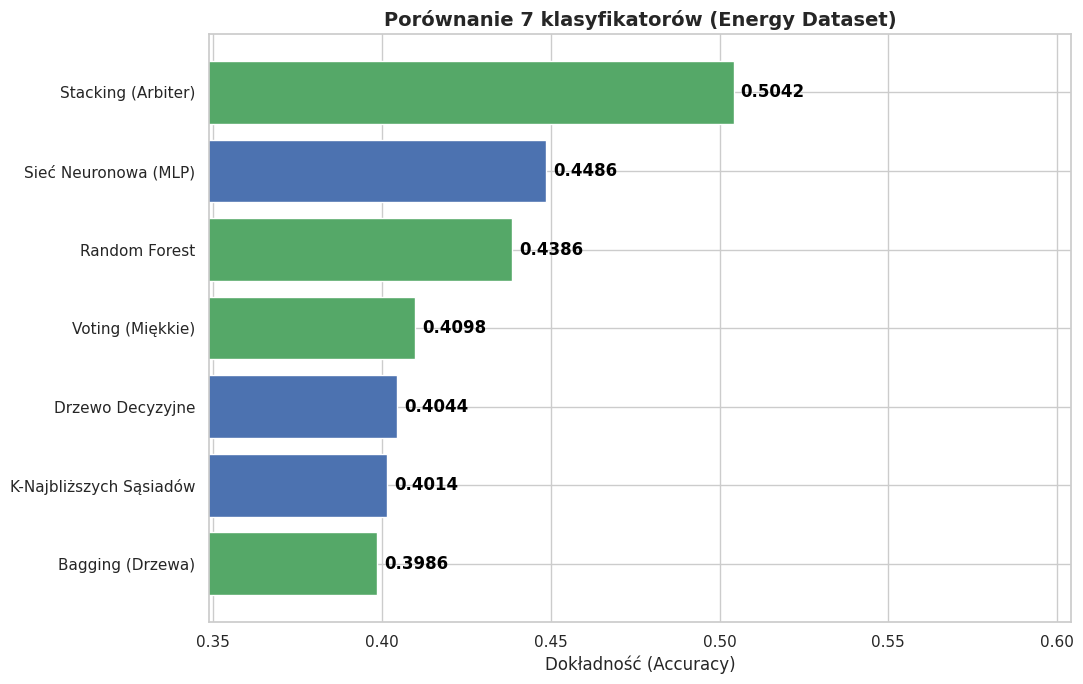

In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Importy uczenia maszynowego
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    VotingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression

# 1. Montowanie dysku Google Colab
try:
    from google.colab import drive
    if not os.path.exists('/content/drive'):
        drive.mount('/content/drive')
    file_path = '/content/drive/MyDrive/Colab Notebooks/energy.csv'
except ImportError:
    file_path = 'energy.csv'

# 2. Wczytanie i przygotowanie danych
print("Wczytywanie pliku energy.csv...")
df = pd.read_csv(file_path)

# Przekształcenie problemu w klasyfikację (0 - niskie zużycie, 1 - wysokie zużycie)
mediana_zuzycia = df['Appliances'].median()
df['Target_Class'] = (df['Appliances'] > mediana_zuzycia).astype(int)

X = df.drop(columns=['date', 'Appliances', 'lights', 'Target_Class', 'rv1', 'rv2'])
y = df['Target_Class'].values

# Próbka 5000 wierszy dla szybkości
X = X.iloc[:5000]
y = y[:5000]

print(f"Rozmiar danych do analizy: Cechy {X.shape}, Cel {y.shape}")

# 3. Definicja klasyfikatorów
clf_knn = KNeighborsClassifier(n_neighbors=5)
clf_dt = DecisionTreeClassifier(max_depth=10, random_state=42)
clf_mlp = MLPClassifier(hidden_layer_sizes=(10, 5), max_iter=1500, random_state=42)
clf_rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
clf_bagging = BaggingClassifier(estimator=clf_dt, n_estimators=50, random_state=42)
clf_voting = VotingClassifier(estimators=[('knn', clf_knn), ('dt', clf_dt), ('mlp', clf_mlp)], voting='soft')
clf_stacking = StackingClassifier(estimators=[('knn', clf_knn), ('dt', clf_dt), ('rf', clf_rf)], final_estimator=LogisticRegression())

classifiers = [
    ('K-Najbliższych Sąsiadów', clf_knn),
    ('Drzewo Decyzyjne', clf_dt),
    ('Sieć Neuronowa (MLP)', clf_mlp),
    ('Bagging (Drzewa)', clf_bagging),
    ('Voting (Miękkie)', clf_voting),
    ('Random Forest', clf_rf),
    ('Stacking (Arbiter)', clf_stacking)
]

# 5. Proces trenowania
results = {}
for name, model in classifiers:
    pipe = make_pipeline(StandardScaler(), model)
    cv_results = cross_validate(pipe, X, y, cv=5, scoring='accuracy')
    mean_score = cv_results['test_score'].mean()
    results[name] = mean_score
    print(f"{name:<25}: Średnia dokładność = {mean_score:.4f}")

# 6. Wykres
results_sorted = dict(sorted(results.items(), key=lambda item: item[1]))
plt.figure(figsize=(11, 7))
sns.set_theme(style="whitegrid")

colors = ['#55A868' if name in ['Bagging (Drzewa)', 'Voting (Miękkie)', 'Random Forest', 'Stacking (Arbiter)'] else '#4C72B0' for name in results_sorted.keys()]

bars = plt.barh(list(results_sorted.keys()), list(results_sorted.values()), color=colors)

# Dynamiczny xlim i poprawione etykiety
plt.bar_label(bars, fmt='%.4f', padding=5, color='black', fontweight='bold')
min_val = min(results.values())
plt.xlim(max(0, min_val - 0.05), max(results.values()) + 0.1)

plt.title('Porównanie 7 klasyfikatorów (Energy Dataset)', fontsize=14, fontweight='bold')
plt.xlabel('Dokładność (Accuracy)', fontsize=12)
plt.tight_layout()
plt.show()

Wczytywanie pliku energy.csv...
Rozmiar ZOPTYMALIZOWANYCH danych: Cechy (5000, 27), Cel (5000,)

Rozpoczęto walidację dla zoptymalizowanych modeli. Proszę czekać...

K-Najbliższych Sąsiadów  : Średnia dokładność = 0.8216
Drzewo Decyzyjne         : Średnia dokładność = 0.8050
Sieć Neuronowa (MLP)     : Średnia dokładność = 0.8270
Bagging (Drzewa)         : Średnia dokładność = 0.8472
Voting (Miękkie)         : Średnia dokładność = 0.8480
Random Forest            : Średnia dokładność = 0.8556
Stacking (Arbiter)       : Średnia dokładność = 0.8574


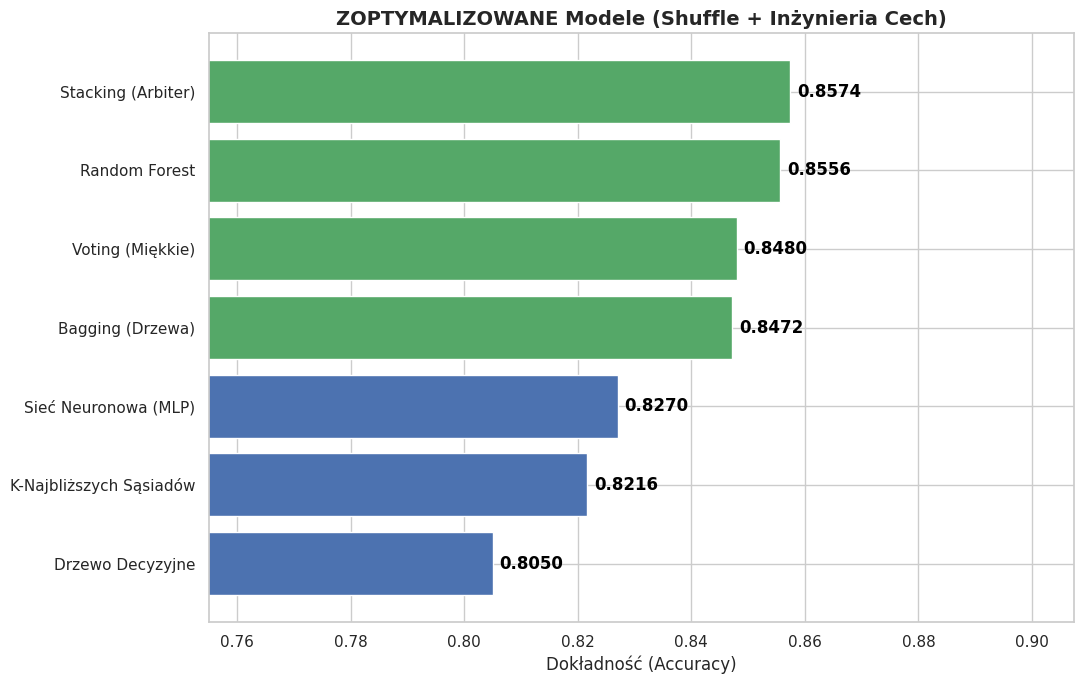

In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Importy uczenia maszynowego
from sklearn.model_selection import KFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    VotingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression

# 1. Montowanie dysku Google Colab
try:
    from google.colab import drive
    if not os.path.exists('/content/drive'):
        drive.mount('/content/drive')
    file_path = '/content/drive/MyDrive/Colab Notebooks/energy.csv'
except ImportError:
    file_path = 'energy.csv'

# 2. Wczytanie danych
print("Wczytywanie pliku energy.csv...")
df = pd.read_csv(file_path)

# --- INŻYNIERIA CECH (FEATURE ENGINEERING) ---
# Zamiana tekstu daty na obiekt DateTime
df['date'] = pd.to_datetime(df['date'])

# Ekstrakcja zachowań czasowych (zużycie energii bardzo zależy od godziny i dnia!)
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# --- PRZEKSZTAŁCENIE CELU ---
mediana_zuzycia = df['Appliances'].median()
df['Target_Class'] = (df['Appliances'] > mediana_zuzycia).astype(int)

# --- LOSOWANIE PRÓBKI (ROZWIĄZANIE PROBLEMU CONCEPT DRIFT) ---
# Bierzemy próbkę 5000, ale całkowicie losową z całego okresu pomiarowego!
df_sample = df.sample(n=5000, random_state=42)

X = df_sample.drop(columns=['date', 'Appliances', 'lights', 'Target_Class', 'rv1', 'rv2'])
y = df_sample['Target_Class'].values

print(f"Rozmiar ZOPTYMALIZOWANYCH danych: Cechy {X.shape}, Cel {y.shape}")

# 3. Definicja klasyfikatorów
clf_knn = KNeighborsClassifier(n_neighbors=5)
clf_dt = DecisionTreeClassifier(max_depth=10, random_state=42)
clf_mlp = MLPClassifier(hidden_layer_sizes=(10, 5), max_iter=1500, random_state=42)
clf_rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
clf_bagging = BaggingClassifier(estimator=clf_dt, n_estimators=50, random_state=42)
clf_voting = VotingClassifier(estimators=[('knn', clf_knn), ('dt', clf_dt), ('mlp', clf_mlp)], voting='soft')
clf_stacking = StackingClassifier(estimators=[('knn', clf_knn), ('dt', clf_dt), ('rf', clf_rf)], final_estimator=LogisticRegression())

classifiers = [
    ('K-Najbliższych Sąsiadów', clf_knn),
    ('Drzewo Decyzyjne', clf_dt),
    ('Sieć Neuronowa (MLP)', clf_mlp),
    ('Bagging (Drzewa)', clf_bagging),
    ('Voting (Miękkie)', clf_voting),
    ('Random Forest', clf_rf),
    ('Stacking (Arbiter)', clf_stacking)
]

# 4. Zoptymalizowana Walidacja Krzyżowa (z włączonym tasowaniem)
# Shuffle=True rozbija jakiekolwiek resztki chronologii
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

results = {}
print("\nRozpoczęto walidację dla zoptymalizowanych modeli. Proszę czekać...\n")

for name, model in classifiers:
    pipe = make_pipeline(StandardScaler(), model)
    cv_results = cross_validate(pipe, X, y, cv=cv_strategy, scoring='accuracy')
    mean_score = cv_results['test_score'].mean()
    results[name] = mean_score
    print(f"{name:<25}: Średnia dokładność = {mean_score:.4f}")

# 5. Wykres z podsumowaniem wyników
results_sorted = dict(sorted(results.items(), key=lambda item: item[1]))
plt.figure(figsize=(11, 7))
sns.set_theme(style="whitegrid")

colors = ['#55A868' if name in ['Bagging (Drzewa)', 'Voting (Miękkie)', 'Random Forest', 'Stacking (Arbiter)'] else '#4C72B0' for name in results_sorted.keys()]

bars = plt.barh(list(results_sorted.keys()), list(results_sorted.values()), color=colors)

plt.bar_label(bars, fmt='%.4f', padding=5, color='black', fontweight='bold')
min_val = min(results.values())
plt.xlim(max(0, min_val - 0.05), max(results.values()) + 0.05)

plt.title('ZOPTYMALIZOWANE Modele (Shuffle + Inżynieria Cech)', fontsize=14, fontweight='bold')
plt.xlabel('Dokładność (Accuracy)', fontsize=12)
plt.tight_layout()
plt.show()